In [5]:
import os
import glob
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier  
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, precision_score, average_precision_score

folder_path = "C:/Users/HP/Desktop/Spring 2025/datasets/"
data_paths = glob.glob(os.path.join(folder_path, "*.parquet"))

def read_dataset(path):
    return pd.read_parquet(path)

def get_variant(path):
    return os.path.basename(path)  

dataframes = {get_variant(path): read_dataset(path) for path in data_paths}

print(f"Number of datasets loaded: {len(dataframes)}")
print(f"Dataset names: {list(dataframes.keys())}")

def evaluate_model(y_test, y_pred, model_name, results):
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_pred)
    
    results[model_name].append((accuracy, f1, recall, roc_auc, precision, pr_auc))
    print(f"{model_name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, Recall: {recall:.4f}, "
          f"ROC AUC: {roc_auc:.4f}, Precision: {precision:.4f}, PR AUC: {pr_auc:.4f}")

results = {"KNN": [], "XGBoost": [], "LSTM": []}

for df_name, df in dataframes.items():
    print(f"\nProcessing dataset: {df_name}")

    label_encoder = LabelEncoder()

    if 'fraud_bool' in df.columns:
        df['fraud_bool'] = label_encoder.fit_transform(df['fraud_bool'])
    else:
        raise ValueError(f"Column 'fraud_bool' not found in dataset {df_name}!")

    features = df.drop(columns=['fraud_bool'])
    labels = df['fraud_bool']

    categorical_columns = features.select_dtypes(exclude=[np.number]).columns
    for column in categorical_columns:
        features[column] = label_encoder.fit_transform(features[column])

    numeric_features = features.select_dtypes(include=[np.number])
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(numeric_features)

    X_train, X_test, y_train, y_test = train_test_split(features_scaled, labels, test_size=0.1, random_state=42)

    def train_model(model, X_train, y_train, X_test):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        return y_pred

    knn_model = KNeighborsClassifier(n_neighbors=5)  
    y_pred_knn = train_model(knn_model, X_train, y_train, X_test)
    evaluate_model(y_test, y_pred_knn, "KNN", results)

    xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    y_pred_xgb = train_model(xgb_model, X_train, y_train, X_test)
    evaluate_model(y_test, y_pred_xgb, "XGBoost", results)

    X_train_lstm = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
    X_test_lstm = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

    early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

    lstm_model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(1, X_train.shape[1])),
        Dropout(0.3),
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    lstm_model.fit(X_train_lstm, y_train, epochs=30, batch_size=64, verbose=1, callbacks=[early_stopping])

    y_pred_lstm = (lstm_model.predict(X_test_lstm) > 0.5).astype(int)
    evaluate_model(y_test, y_pred_lstm, "LSTM", results)

def compute_average(results):
    avg_results = {}
    for model, scores in results.items():
        avg_scores = np.mean(scores, axis=0)  
        avg_results[model] = avg_scores
        print(f"\n{model} - Average Accuracy: {avg_scores[0]:.4f}, "
              f"F1 Score: {avg_scores[1]:.4f}, Recall: {avg_scores[2]:.4f}, "
              f"ROC AUC: {avg_scores[3]:.4f}, Precision: {avg_scores[4]:.4f}, "
              f"PR AUC: {avg_scores[5]:.4f}")
    return avg_results

print("\n===== Overall Model Performance Across All Datasets =====")
average_results = compute_average(results)

Number of datasets loaded: 6
Dataset names: ['Base.parquet', 'Variant I.parquet', 'Variant II.parquet', 'Variant III.parquet', 'Variant IV.parquet', 'Variant V.parquet']

Processing dataset: Base.parquet
KNN - Accuracy: 0.9893, F1: 0.0343, Recall: 0.0183, ROC AUC: 0.5089, Precision: 0.2754, PR AUC: 0.0152


C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\xgboost\core.py:158: UserWarning: [09:50:04] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost - Accuracy: 0.9893, F1: 0.0649, Recall: 0.0356, ROC AUC: 0.5175, Precision: 0.3663, PR AUC: 0.0231


C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 204s 13ms/step - accuracy: 0.9887 - loss: 0.0610
Epoch 2/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 171s 12ms/step - accuracy: 0.9889 - loss: 0.0479
Epoch 3/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 179s 13ms/step - accuracy: 0.9889 - loss: 0.0473
Epoch 4/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 169s 12ms/step - accuracy: 0.9890 - loss: 0.0465
Epoch 5/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 166s 12ms/step - accuracy: 0.9888 - loss: 0.0476
Epoch 6/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 171s 12ms/step - accuracy: 0.9890 - loss: 0.0461
Epoch 7/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 166s 12ms/step - accuracy: 0.9888 - loss: 0.0467
Epoch 8/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 131s 9ms/step - accuracy: 0.9889 - loss: 0.0459
Epoch 9/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 133s 9ms/step - accuracy: 0.9890 - loss: 0.0453
Epoch 10/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 146s 10ms/step - accuracy: 0.9890 - loss: 0.0456
Epoch 11/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 151s 11ms/step - accuracy:

...

Epoch 1/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 117s 8ms/step - accuracy: 0.9883 - loss: 0.0618
Epoch 2/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 107s 8ms/step - accuracy: 0.9887 - loss: 0.0489
Epoch 3/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 108s 8ms/step - accuracy: 0.9890 - loss: 0.0473
Epoch 4/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 108s 8ms/step - accuracy: 0.9889 - loss: 0.0468
Epoch 5/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 108s 8ms/step - accuracy: 0.9890 - loss: 0.0464
Epoch 6/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 108s 8ms/step - accuracy: 0.9890 - loss: 0.0458
Epoch 7/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 164s 9ms/step - accuracy: 0.9891 - loss: 0.0452
Epoch 8/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 118s 8ms/step - accuracy: 0.9889 - loss: 0.0458
Epoch 9/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 120s 9ms/step - accuracy: 0.9890 - loss: 0.0456
Epoch 10/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 125s 9ms/step - accuracy: 0.9889 - loss: 0.0457
Epoch 11/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 127s 9ms/step - accuracy: 0.9890 -

C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\xgboost\core.py:158: UserWarning: [16:35:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost - Accuracy: 0.9916, F1: 0.4237, Recall: 0.2865, ROC AUC: 0.6429, Precision: 0.8127, PR AUC: 0.2405


C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 193s 13ms/step - accuracy: 0.9902 - loss: 0.0525
Epoch 2/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 178s 13ms/step - accuracy: 0.9912 - loss: 0.0377
Epoch 3/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 195s 14ms/step - accuracy: 0.9913 - loss: 0.0371
Epoch 4/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 140s 10ms/step - accuracy: 0.9914 - loss: 0.0366
Epoch 5/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 158s 11ms/step - accuracy: 0.9914 - loss: 0.0364
Epoch 6/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 153s 11ms/step - accuracy: 0.9914 - loss: 0.0356
Epoch 7/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 140s 10ms/step - accuracy: 0.9914 - loss: 0.0356
Epoch 8/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 141s 10ms/step - accuracy: 0.9916 - loss: 0.0348
Epoch 9/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 139s 10ms/step - accuracy: 0.9915 - loss: 0.0351
Epoch 10/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 139s 10ms/step - accuracy: 0.9916 - loss: 0.0345
Epoch 11/30
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 140s 10ms/step - accurac

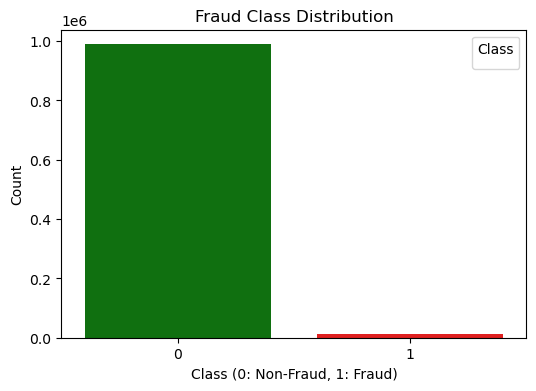

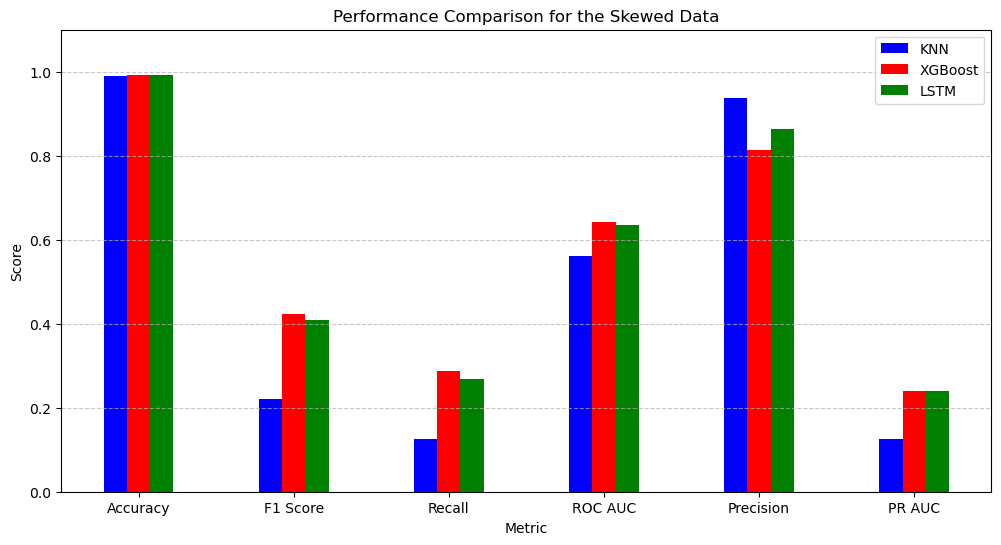

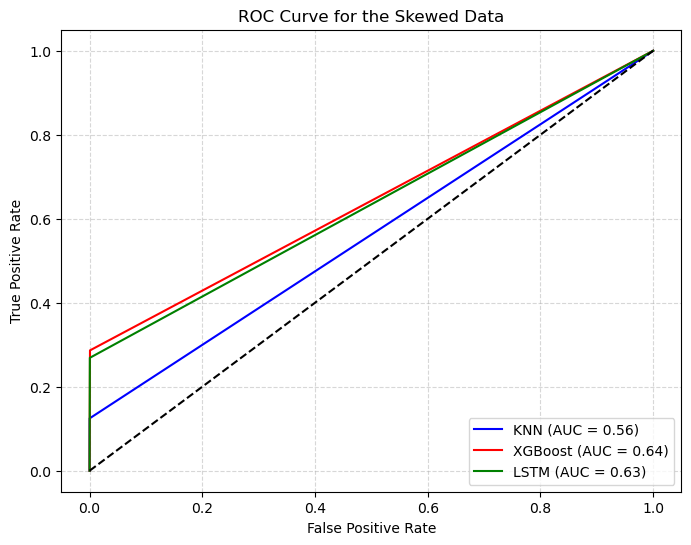

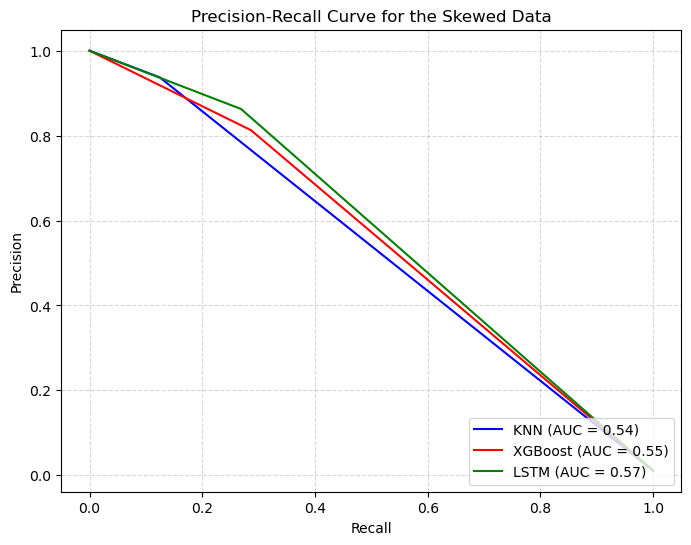

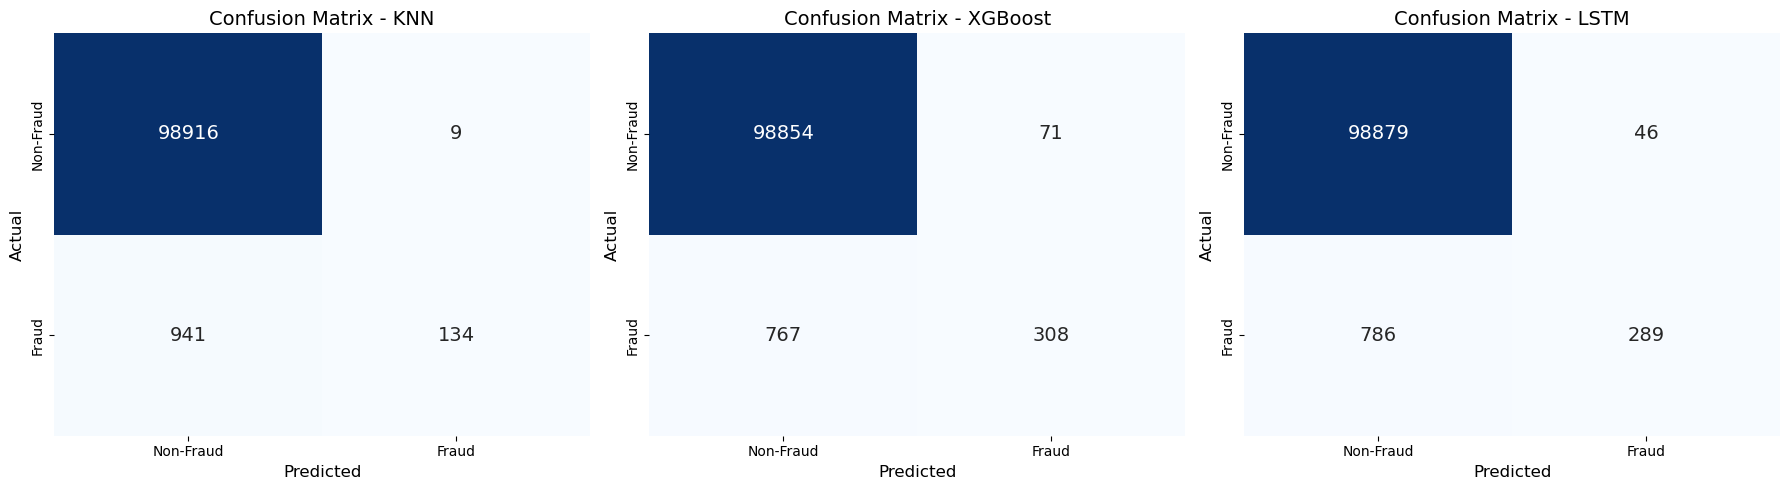

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import (accuracy_score, f1_score, recall_score, roc_auc_score, 
                           roc_curve, auc, confusion_matrix, precision_score, 
                           average_precision_score, precision_recall_curve)

plt.figure(figsize=(6,4))
ax = sns.countplot(x=labels, palette={0: 'green', 1: 'red'})  
plt.title("Fraud Class Distribution")
plt.xlabel("Class (0: Non-Fraud, 1: Fraud)")
plt.ylabel("Count")

handles, _ = ax.get_legend_handles_labels()
plt.legend(handles, ["Non-Fraud", "Fraud"], title="Class", loc='upper right')
plt.show()

models = ["KNN", "XGBoost", "LSTM"]  
metrics = ["Accuracy", "F1 Score", "Recall", "ROC AUC", "Precision", "PR AUC"]
values = [
    [
        accuracy_score(y_test, y_pred_knn), 
        f1_score(y_test, y_pred_knn), 
        recall_score(y_test, y_pred_knn), 
        roc_auc_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_knn),
        average_precision_score(y_test, y_pred_knn)
    ],
    [
        accuracy_score(y_test, y_pred_xgb), 
        f1_score(y_test, y_pred_xgb), 
        recall_score(y_test, y_pred_xgb), 
        roc_auc_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        average_precision_score(y_test, y_pred_xgb)
    ],
    [
        accuracy_score(y_test, y_pred_lstm), 
        f1_score(y_test, y_pred_lstm), 
        recall_score(y_test, y_pred_lstm), 
        roc_auc_score(y_test, y_pred_lstm),
        precision_score(y_test, y_pred_lstm),
        average_precision_score(y_test, y_pred_lstm)
    ]
]

df_metrics = pd.DataFrame(values, columns=metrics, index=models)

plt.figure(figsize=(12,6))
bar_width = 0.15
x = np.arange(len(metrics))

plt.bar(x - bar_width, df_metrics.loc["KNN"], width=bar_width, label="KNN", color='blue')
plt.bar(x, df_metrics.loc["XGBoost"], width=bar_width, label="XGBoost", color='red')  
plt.bar(x + bar_width, df_metrics.loc["LSTM"], width=bar_width, label="LSTM", color='green')

plt.xticks(x, metrics)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Performance Comparison for the Skewed Data")
plt.legend(loc='upper right')
plt.ylim(0, 1.1)  
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(8,6))

for model_name, y_pred, color in zip(
    ["KNN", "XGBoost", "LSTM"],
    [y_pred_knn, y_pred_xgb, y_pred_lstm], 
    ['blue', 'red', 'green']
):
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f"{model_name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for the Skewed Data")
plt.legend(loc='lower right')
plt.grid(linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(8,6))

for model_name, y_pred, color in zip(
    ["KNN", "XGBoost", "LSTM"],
    [y_pred_knn, y_pred_xgb, y_pred_lstm], 
    ['blue', 'red', 'green']
):
    precision, recall, _ = precision_recall_curve(y_test, y_pred)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, color=color, label=f"{model_name} (AUC = {pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for the Skewed Data")
plt.legend(loc='lower right')
plt.grid(linestyle='--', alpha=0.5)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_pred, model_name in zip(axes, [y_pred_knn, y_pred_xgb, y_pred_lstm], models):  
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
               annot_kws={"size": 14}, cbar=False)
    ax.set_title(f"Confusion Matrix - {model_name}", fontsize=14)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)
    ax.set_xticklabels(['Non-Fraud', 'Fraud'])
    ax.set_yticklabels(['Non-Fraud', 'Fraud'])

plt.tight_layout()
plt.show()

In [1]:
import os
import glob
import pandas as pd
import tensorflow as tf
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (accuracy_score, f1_score, recall_score, 
                           roc_auc_score, precision_score, average_precision_score,
                           precision_recall_curve)
from sklearn.utils.class_weight import compute_class_weight

folder_path = "C:/Users/HP/Desktop/Spring 2025/datasets/"
data_paths = glob.glob(os.path.join(folder_path, "*.parquet"))

def read_dataset(path):
    return pd.read_parquet(path)

def get_variant(path):
    return os.path.basename(path)

dataframes = {get_variant(path): read_dataset(path) for path in data_paths}

def evaluate_model(y_test, y_pred, y_proba, model_name, results):
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_proba)
    
    results[model_name].append((accuracy, f1, recall, roc_auc, precision, pr_auc))
    print(f"{model_name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, Recall: {recall:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}, Precision: {precision:.4f}, PR AUC: {pr_auc:.4f}\n")
    return results

results = {
    "XGBoost": [], 
    "KNN": [], 
    "LSTM": []
}

for df_name, df in dataframes.items():
    print(f"\n{'='*50}")
    print(f"Processing dataset: {df_name}")
    print(f"{'='*50}")

    label_encoder = LabelEncoder()
    if 'fraud_bool' in df.columns:
        df['fraud_bool'] = label_encoder.fit_transform(df['fraud_bool'])
        fraud_ratio = df['fraud_bool'].mean()
        print(f"Fraud rate in dataset: {fraud_ratio:.4f}")
    else:
        raise ValueError(f"Column 'fraud_bool' not found in dataset {df_name}!")

    features = df.drop(columns=['fraud_bool'])
    labels = df['fraud_bool']

    categorical_columns = features.select_dtypes(exclude=[np.number]).columns
    for column in categorical_columns:
        features[column] = label_encoder.fit_transform(features[column])

    numeric_features = features.select_dtypes(include=[np.number])
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(numeric_features)

    smote = SMOTE(sampling_strategy=0.5, random_state=42, k_neighbors=5)
    X_resampled, y_resampled = smote.fit_resample(features_scaled, labels)
    print(f"Class distribution after SMOTE: {pd.Series(y_resampled).value_counts(normalize=True).to_dict()}")

    X_train, X_test, y_train, y_test = train_test_split(
        X_resampled, y_resampled, 
        test_size=0.1, 
        random_state=42,
        stratify=y_resampled
    )

    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    def train_xgboost(X_train, y_train, X_test):
        model = XGBClassifier(
            n_estimators=300,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
            random_state=42,
            eval_metric=['aucpr', 'logloss'],
            early_stopping_rounds=10
        )
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        return y_pred, y_proba

    def train_knn(X_train, y_train, X_test):
        model = KNeighborsClassifier(
            n_neighbors=7,
            weights='distance',
            algorithm='auto',
            leaf_size=30,
            p=2  # Euclidean distance
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        return y_pred, y_proba

    def train_lstm(X_train, y_train, X_test):
        X_train_reshaped = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
        X_test_reshaped = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
        
        model = Sequential([
            LSTM(128, return_sequences=True, input_shape=(1, X_train.shape[1]), dropout=0.2, recurrent_dropout=0.2),
            LSTM(64, dropout=0.2, recurrent_dropout=0.2),
            Dense(32, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
        
        model.compile(
            loss='binary_crossentropy',
            optimizer='adam',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.AUC(name='prc', curve='PR')]
        )
        
        early_stopping = EarlyStopping(
            monitor='val_prc',
            patience=10,
            mode='max',
            restore_best_weights=True
        )
        
        history = model.fit(
            X_train_reshaped, y_train,
            epochs=30,
            batch_size=128,
            validation_split=0.2,
            class_weight=class_weight_dict,
            callbacks=[early_stopping],
            verbose=1
        )
        
        y_proba = model.predict(X_test_reshaped).flatten()
        y_pred = (y_proba > 0.5).astype(int)
        return y_pred, y_proba

    print("\nTraining XGBoost...")
    y_pred_xgb, y_proba_xgb = train_xgboost(X_train, y_train, X_test)
    results = evaluate_model(y_test, y_pred_xgb, y_proba_xgb, "XGBoost", results)
    
    print("Training KNN...")
    y_pred_knn, y_proba_knn = train_knn(X_train, y_train, X_test)
    results = evaluate_model(y_test, y_pred_knn, y_proba_knn, "KNN", results)
    
    print("Training LSTM...")
    y_pred_lstm, y_proba_lstm = train_lstm(X_train, y_train, X_test)
    results = evaluate_model(y_test, y_pred_lstm, y_proba_lstm, "LSTM", results)

def compute_average(results):
    avg_results = {}
    print("\n" + "="*60)
    print("OVERALL MODEL PERFORMANCE ACROSS ALL DATASETS")
    print("="*60)
    
    for model, scores in results.items():
        avg_scores = np.mean(scores, axis=0)
        std_scores = np.std(scores, axis=0)
        avg_results[model] = (avg_scores, std_scores)
        
        print(f"\n{model}:")
        print(f"Accuracy: {avg_scores[0]:.4f} ± {std_scores[0]:.4f}")
        print(f"F1 Score: {avg_scores[1]:.4f} ± {std_scores[1]:.4f}")
        print(f"Recall:   {avg_scores[2]:.4f} ± {std_scores[2]:.4f}")
        print(f"ROC AUC:  {avg_scores[3]:.4f} ± {std_scores[3]:.4f}")
        print(f"Precision:{avg_scores[4]:.4f} ± {std_scores[4]:.4f}")
        print(f"PR AUC:   {avg_scores[5]:.4f} ± {std_scores[5]:.4f}")
    
    return avg_results

final_results = compute_average(results)

C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



Processing dataset: Base.parquet
Fraud rate in dataset: 0.0110
Class distribution after SMOTE: {0: 0.6666668913671858, 1: 0.3333331086328142}

Training XGBoost...
XGBoost - Accuracy: 0.9904, F1: 0.9855, Recall: 0.9783
ROC AUC: 0.9980, Precision: 0.9929, PR AUC: 0.9972

Training KNN...
KNN - Accuracy: 0.9385, F1: 0.9156, Recall: 1.0000
ROC AUC: 0.9890, Precision: 0.8443, PR AUC: 0.9579

Training LSTM...


C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 102s 11ms/step - accuracy: 0.7985 - auc: 0.8846 - loss: 0.4265 - prc: 0.7949 - val_accuracy: 0.8344 - val_auc: 0.9218 - val_loss: 0.3656 - val_prc: 0.8520
Epoch 2/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 91s 11ms/step - accuracy: 0.8260 - auc: 0.9103 - loss: 0.3780 - prc: 0.8314 - val_accuracy: 0.8239 - val_auc: 0.9321 - val_loss: 0.3825 - val_prc: 0.8666
Epoch 3/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 84s 10ms/step - accuracy: 0.8339 - auc: 0.9188 - loss: 0.3596 - prc: 0.8437 - val_accuracy: 0.8355 - val_auc: 0.9401 - val_loss: 0.3625 - val_prc: 0.8782
Epoch 4/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 85s 10ms/step - accuracy: 0.8384 - auc: 0.9232 - loss: 0.3491 - prc: 0.8503 - val_accuracy: 0.8440 - val_auc: 0.9444 - val_loss: 0.3450 - val_prc: 0.8843
Epoch 5/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 86s 10ms/step - accuracy: 0.8415 - auc: 0.9266 - loss: 0.3409 - prc: 0.8552 - val_accuracy: 0.8307 - val_auc: 0.9473 - val_loss: 0.3711 - val_prc: 0.8881
Epoch 6/30
8345/834

C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

Epoch 1/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 95s 10ms/step - accuracy: 0.8576 - auc: 0.9422 - loss: 0.3026 - prc: 0.9006 - val_accuracy: 0.8982 - val_auc: 0.9713 - val_loss: 0.2275 - val_prc: 0.9469
Epoch 2/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 80s 10ms/step - accuracy: 0.8889 - auc: 0.9630 - loss: 0.2445 - prc: 0.9329 - val_accuracy: 0.9037 - val_auc: 0.9750 - val_loss: 0.2161 - val_prc: 0.9527
Epoch 3/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 82s 10ms/step - accuracy: 0.8951 - auc: 0.9669 - loss: 0.2306 - prc: 0.9389 - val_accuracy: 0.9115 - val_auc: 0.9784 - val_loss: 0.1993 - val_prc: 0.9580
Epoch 4/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 81s 10ms/step - accuracy: 0.8998 - auc: 0.9700 - loss: 0.2189 - prc: 0.9433 - val_accuracy: 0.9123 - val_auc: 0.9805 - val_loss: 0.1966 - val_prc: 0.9611
Epoch 5/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 86s 10ms/step - accuracy: 0.9028 - auc: 0.9716 - loss: 0.2128 - prc: 0.9461 - val_accuracy: 0.9158 - val_auc: 0.9820 - val_loss: 0.1896 - val_prc: 0.9636
Epoch 6/30
8345/8345

C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 81s 9ms/step - accuracy: 0.8009 - auc: 0.8894 - loss: 0.4168 - prc: 0.7978 - val_accuracy: 0.8315 - val_auc: 0.9262 - val_loss: 0.3719 - val_prc: 0.8574
Epoch 2/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 68s 8ms/step - accuracy: 0.8306 - auc: 0.9153 - loss: 0.3669 - prc: 0.8375 - val_accuracy: 0.8319 - val_auc: 0.9351 - val_loss: 0.3602 - val_prc: 0.8717
Epoch 3/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 71s 8ms/step - accuracy: 0.8376 - auc: 0.9223 - loss: 0.3510 - prc: 0.8480 - val_accuracy: 0.8423 - val_auc: 0.9417 - val_loss: 0.3477 - val_prc: 0.8803
Epoch 4/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 72s 9ms/step - accuracy: 0.8413 - auc: 0.9265 - loss: 0.3409 - prc: 0.8539 - val_accuracy: 0.8444 - val_auc: 0.9472 - val_loss: 0.3412 - val_prc: 0.8883
Epoch 5/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 71s 9ms/step - accuracy: 0.8452 - auc: 0.9297 - loss: 0.3328 - prc: 0.8586 - val_accuracy: 0.8470 - val_auc: 0.9505 - val_loss: 0.3383 - val_prc: 0.8932
Epoch 6/30
8345/8345 ━━━━

C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 98s 10ms/step - accuracy: 0.8360 - auc: 0.9235 - loss: 0.3490 - prc: 0.8716 - val_accuracy: 0.8747 - val_auc: 0.9578 - val_loss: 0.2769 - val_prc: 0.9243
Epoch 2/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 81s 10ms/step - accuracy: 0.8684 - auc: 0.9484 - loss: 0.2884 - prc: 0.9084 - val_accuracy: 0.8809 - val_auc: 0.9644 - val_loss: 0.2626 - val_prc: 0.9342
Epoch 3/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 78s 9ms/step - accuracy: 0.8749 - auc: 0.9533 - loss: 0.2740 - prc: 0.9156 - val_accuracy: 0.8859 - val_auc: 0.9678 - val_loss: 0.2538 - val_prc: 0.9386
Epoch 4/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 89s 11ms/step - accuracy: 0.8800 - auc: 0.9572 - loss: 0.2620 - prc: 0.9212 - val_accuracy: 0.8890 - val_auc: 0.9715 - val_loss: 0.2451 - val_prc: 0.9444
Epoch 5/30
8345/8345 ━━━━━━━━━━━━━━━━━━━━ 86s 10ms/step - accuracy: 0.8832 - auc: 0.9593 - loss: 0.2551 - prc: 0.9245 - val_accuracy: 0.8935 - val_auc: 0.9742 - val_loss: 0.2412 - val_prc: 0.9487
Epoch 6/30
8345/8345 

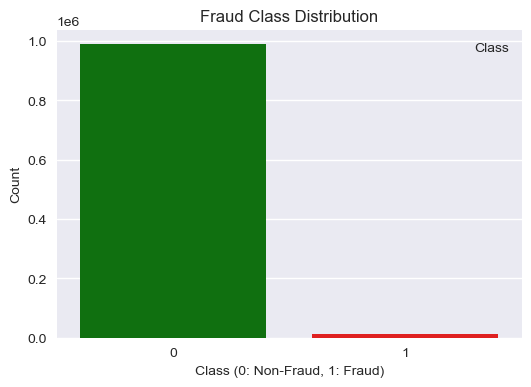

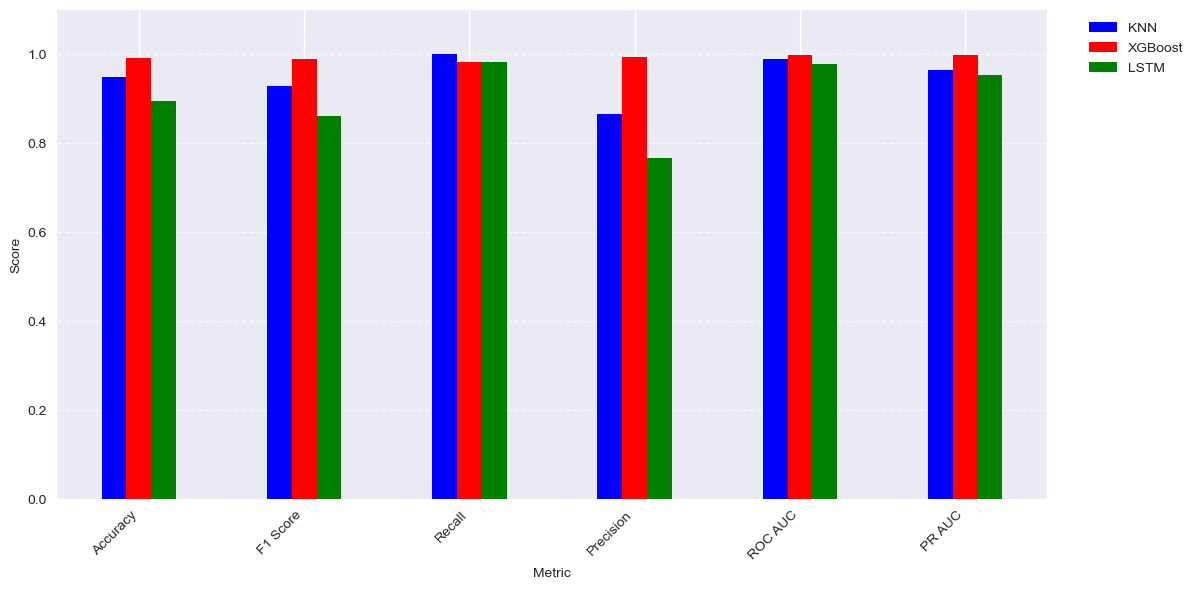

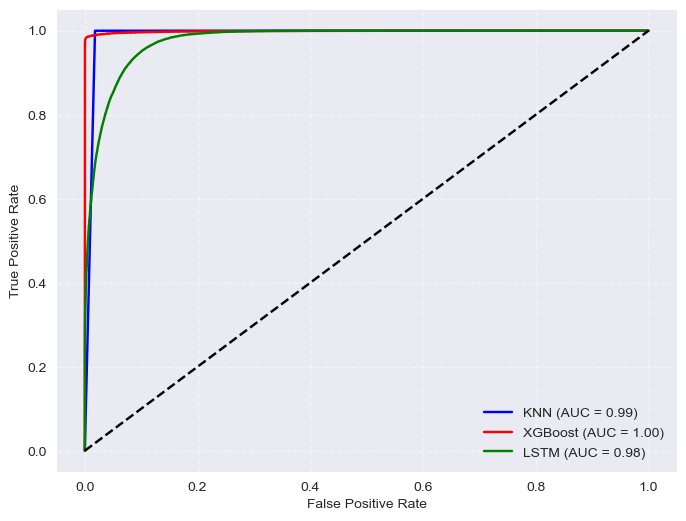

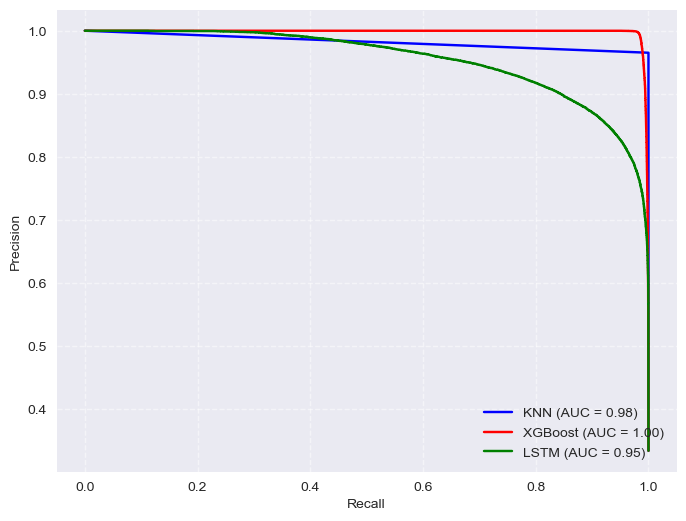

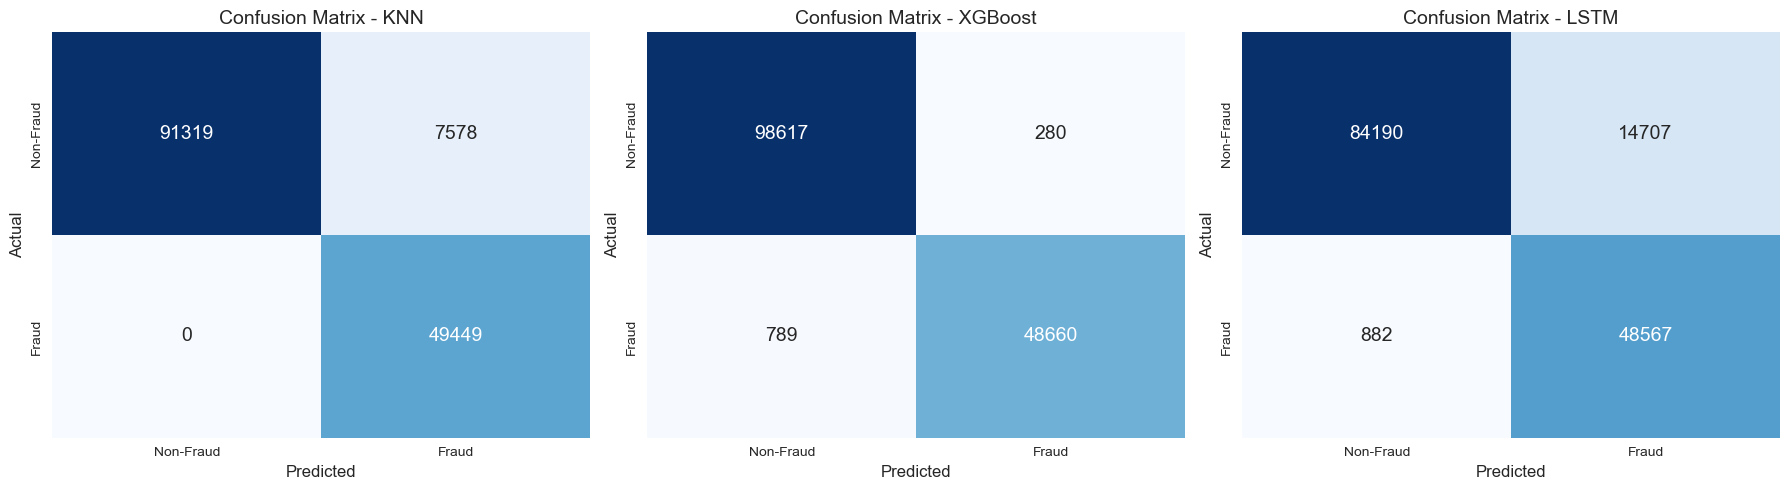

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import (accuracy_score, f1_score, recall_score, 
                           roc_auc_score, roc_curve, auc, confusion_matrix, 
                           precision_score, average_precision_score, 
                           precision_recall_curve)

plt.figure(figsize=(6,4))
ax = sns.countplot(x=labels, palette={0: 'green', 1: 'red'})
plt.title("Fraud Class Distribution")
plt.xlabel("Class (0: Non-Fraud, 1: Fraud)")
plt.ylabel("Count")
handles, _ = ax.get_legend_handles_labels()
plt.legend(handles, ["Non-Fraud", "Fraud"], title="Class", loc='upper right')
plt.show()

models = ["KNN", "XGBoost", "LSTM"]  
metrics = ["Accuracy", "F1 Score", "Recall", "Precision", "ROC AUC", "PR AUC"]
values = [
    [
        accuracy_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_knn),
        roc_auc_score(y_test, y_proba_knn),  
        average_precision_score(y_test, y_proba_knn)  
    ],
    [
        accuracy_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        roc_auc_score(y_test, y_proba_xgb),  
        average_precision_score(y_test, y_proba_xgb)  
    ],
    [
        accuracy_score(y_test, y_pred_lstm),
        f1_score(y_test, y_pred_lstm),
        recall_score(y_test, y_pred_lstm),
        precision_score(y_test, y_pred_lstm),
        roc_auc_score(y_test, y_proba_lstm),  
        average_precision_score(y_test, y_proba_lstm)  
    ]
]

df_metrics = pd.DataFrame(values, columns=metrics, index=models)

plt.figure(figsize=(12,6))
bar_width = 0.15
x = np.arange(len(metrics))

plt.bar(x - bar_width, df_metrics.loc["KNN"], width=bar_width, label="KNN", color='blue')
plt.bar(x, df_metrics.loc["XGBoost"], width=bar_width, label="XGBoost", color='red')
plt.bar(x + bar_width, df_metrics.loc["LSTM"], width=bar_width, label="LSTM", color='green')

plt.xticks(x, metrics, rotation=45, ha='right')
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("")
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))

for model_name, y_proba, color in zip(
    ["KNN", "XGBoost", "LSTM"],
    [y_proba_knn, y_proba_xgb, y_proba_lstm], 
    ['blue', 'red', 'green']
):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f"{model_name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("")
plt.legend(loc='lower right')
plt.grid(linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(8,6))

for model_name, y_proba, color in zip(
    ["KNN", "XGBoost", "LSTM"],
    [y_proba_knn, y_proba_xgb, y_proba_lstm],  
    ['blue', 'red', 'green']
):
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, color=color, label=f"{model_name} (AUC = {pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("")
plt.legend(loc='lower right')
plt.grid(linestyle='--', alpha=0.5)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_pred, model_name in zip(axes, [y_pred_knn, y_pred_xgb, y_pred_lstm], models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
               annot_kws={"size": 14}, cbar=False)
    ax.set_title(f"Confusion Matrix - {model_name}", fontsize=14)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)
    ax.set_xticklabels(['Non-Fraud', 'Fraud'])
    ax.set_yticklabels(['Non-Fraud', 'Fraud'])

plt.tight_layout()
plt.show()